# Renewables in Electricity Markets: System Perspective

This is the solution to Assignment 1 proposed in the course "Renewables in Electricity Markets" from DTU in 2025.

The chosen system is the IEEE 24-bus test reliability system, shown in the figure below. Data is in the file IEEE 24-bus reliability test system - data.xlsx. 

# ![System](img/System.png)

## Step 1: Copper-Plate, Single Hour

In this first step, we will ignore all network constraints and solve the problem as if the system was a copper-plate. We will also only consider a single hour of operation: the hour with the highest demand. Given there are no time variables the only technical description that will be included from generators is the maximum power output.

### Input data

In [1]:
# Import the libraries to be used
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import linopy
np.random.seed(42)

#### Read data

In [ ]:
# system data
data = pd.read_excel('data/IEEE 24-bus reliability test system - data.xlsx', sheet_name=None)
print(data.keys())

dict_keys(['Generators', 'Costs', 'SystemLoadProfile', 'LoadDist', 'BidTypes', 'Lines', 'WindFarms', 'LineModification'])


In [3]:
#dict_keys(['Generators', 'Costs', 'SystemLoadProfile', 'LoadDist', 'BidTypes', 'Lines', 'WindFarms', 'LineModification'])
generators = data['Generators']
costs = data['Costs']
load_profile = data['SystemLoadProfile']
load_dist = data['LoadDist']
load_bid_types = data['BidTypes']
lines = data['Lines']
wind_farms = data['WindFarms']
line_modification = data['LineModification']

In [ ]:
# windfarm data
wind_production_dk = pd.read_csv('data/ninja_wind_55.4104_12.3039_corrected.csv', skiprows=3)

#### Handle demand data

In [5]:
# Select the hour with the highest demand
max_load_index = load_profile.sum(axis=1).idxmax()
total_load = load_profile.loc[max_load_index]['System_demand_MW']
print(f"Hour with highest demand: {max_load_index},\nTotal load: {total_load} MW")

Hour with highest demand: 18,
Total load: 2650.5 MW


In [6]:
# Assign demand to each bus based on the load distribution
demand_max_load = load_dist.copy()
demand_max_load['Demand_MW'] = demand_max_load['Percent_of_system_load'] * total_load / 100

In [7]:
# create demand bids: Load (id), Node (id), Quantity (MW), Price ($/MWh)
demand_bid = demand_max_load.merge(load_bid_types, left_on='Load_type', right_on='Load_type', how='left')
demand_bid['Quantity_MW'] = demand_bid['Demand_MW']*demand_bid['Quantity_perc']/100
demand_bid = demand_bid[['Load', 'Node', 'Quantity_MW', 'Price_$/MWh']]


In [8]:
# generate total demand bidding curve
demand_bid.sort_values('Price_$/MWh', inplace=True, ascending=False)
demand_bid['Cumulative_Demand_MW'] = demand_bid['Quantity_MW'].cumsum()
demand_bid = demand_bid.reset_index(drop=True).reset_index(names='bid')
demand_bid.head(10)

,bid,Load,Node,Quantity_MW,Price_$/MWh,Cumulative_Demand_MW
0,0,1,1,90.64710,2000,90.64710
1,1,5,5,59.63625,2000,150.28335
2,2,12,14,162.21060,2000,312.49395
3,3,11,13,246.49650,2000,558.99045
4,4,14,16,83.49075,2000,642.48120
5,5,10,10,162.21060,2000,804.69180
6,6,9,9,145.51245,2000,950.20425
7,7,8,8,143.12700,2000,1093.33125
8,8,15,18,310.10850,2000,1403.43975
9,9,13,15,294.20550,2000,1697.64525


#### Handle WindFarm data

In [9]:
#select 6 random days to simulate the wind production of each generator
np.random.seed(42)
wind_production_dk['local_time'] = pd.to_datetime(wind_production_dk['local_time'])
wind_production_dk['day'] = wind_production_dk['local_time'].dt.date
random_days = np.random.choice(wind_production_dk['day'].unique(), size=len(wind_farms), replace=False)
wind_production_sample = wind_production_dk[wind_production_dk['day'].isin(random_days)]
# assign one day to one zone windfarm
wind_production_sample['WindFarm'] = wind_production_sample['day'].apply(lambda x: random_days.tolist().index(x)+1)
wind_production_sample['hour'] = wind_production_sample['local_time'].dt.hour

In [10]:
wind_forecast_generation = wind_production_sample.merge(wind_farms, on='WindFarm', how='left')
wind_forecast_generation['Generation_MW'] = wind_forecast_generation['Installed_Capacity_MW'] * wind_forecast_generation['electricity']
wind_forecast_generation = wind_forecast_generation[['WindFarm', 'Node', 'hour', 'Generation_MW']].sort_values(['WindFarm', 'hour'])

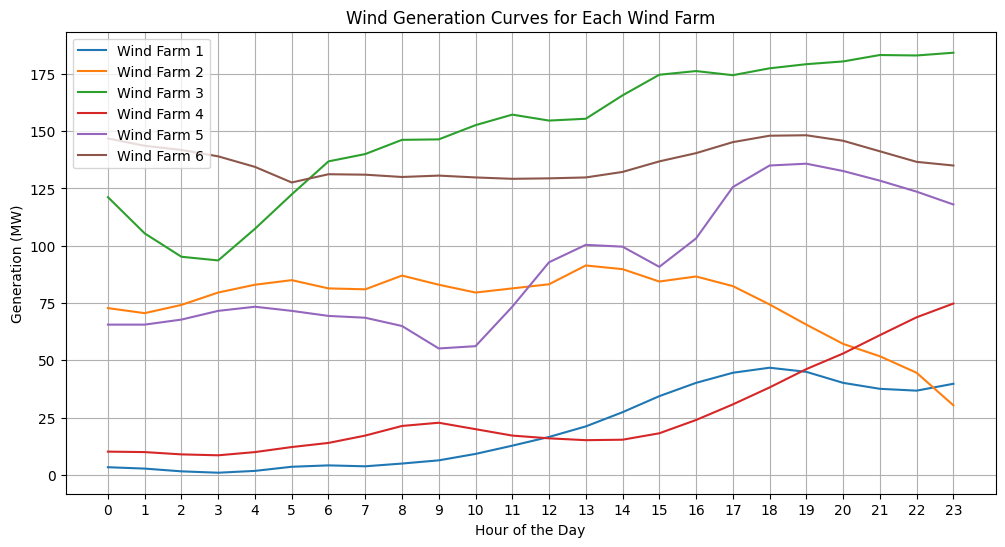

In [11]:
# plot each generation curve
plt.figure(figsize=(12, 6))

for wind_farm in wind_forecast_generation['WindFarm'].unique():
    subset = wind_forecast_generation[wind_forecast_generation['WindFarm'] == wind_farm]
    plt.plot(subset['hour'], subset['Generation_MW'], label=f'Wind Farm {wind_farm}')
plt.title('Wind Generation Curves for Each Wind Farm')
plt.xlabel('Hour of the Day')
plt.ylabel('Generation (MW)')
plt.xticks(range(24))
plt.legend()
plt.grid()
plt.show()

#### Handle supply data

In [12]:
# wind availability at max demand hour
wind_at_max_load = wind_forecast_generation[wind_forecast_generation['hour'] == max_load_index]
wind_at_max_load['Ci_$/MWh'] = 0
wind_at_max_load['WindFarm'] = 'W' + wind_at_max_load['WindFarm'].astype(str)
wind_at_max_load.rename(columns={'Generation_MW': 'Pmax_MW', 'WindFarm': 'Unit'}, inplace=True)
wind_at_max_load = wind_at_max_load[['Unit', 'Pmax_MW', 'Ci_$/MWh']]

In [13]:
available_generation = generators[['Unit', 'Pmax_MW']].merge(costs[['Unit', 'Ci_$/MWh']], on='Unit')
available_generation['Unit'] = 'G' + available_generation['Unit'].astype(str)
available_generation = pd.concat([available_generation, wind_at_max_load], ignore_index=True)

In [14]:
merit_order = available_generation.sort_values(['Ci_$/MWh','Pmax_MW'])
merit_order['Cumulative_Pmax'] = merit_order['Pmax_MW'].cumsum()

In [15]:
merit_order

,Unit,Pmax_MW,Ci_$/MWh,Cumulative_Pmax
15,W4,38.2,0.00,38.2
12,W1,46.8,0.00,85.0
13,W2,74.4,0.00,159.4
16,W5,135.0,0.00,294.4
17,W6,148.0,0.00,442.4
14,W3,177.4,0.00,619.8
9,G10,300.0,0.00,919.8
8,G9,400.0,5.47,1319.8
7,G8,400.0,6.02,1719.8
5,G6,155.0,10.52,1874.8


#### Plot curves

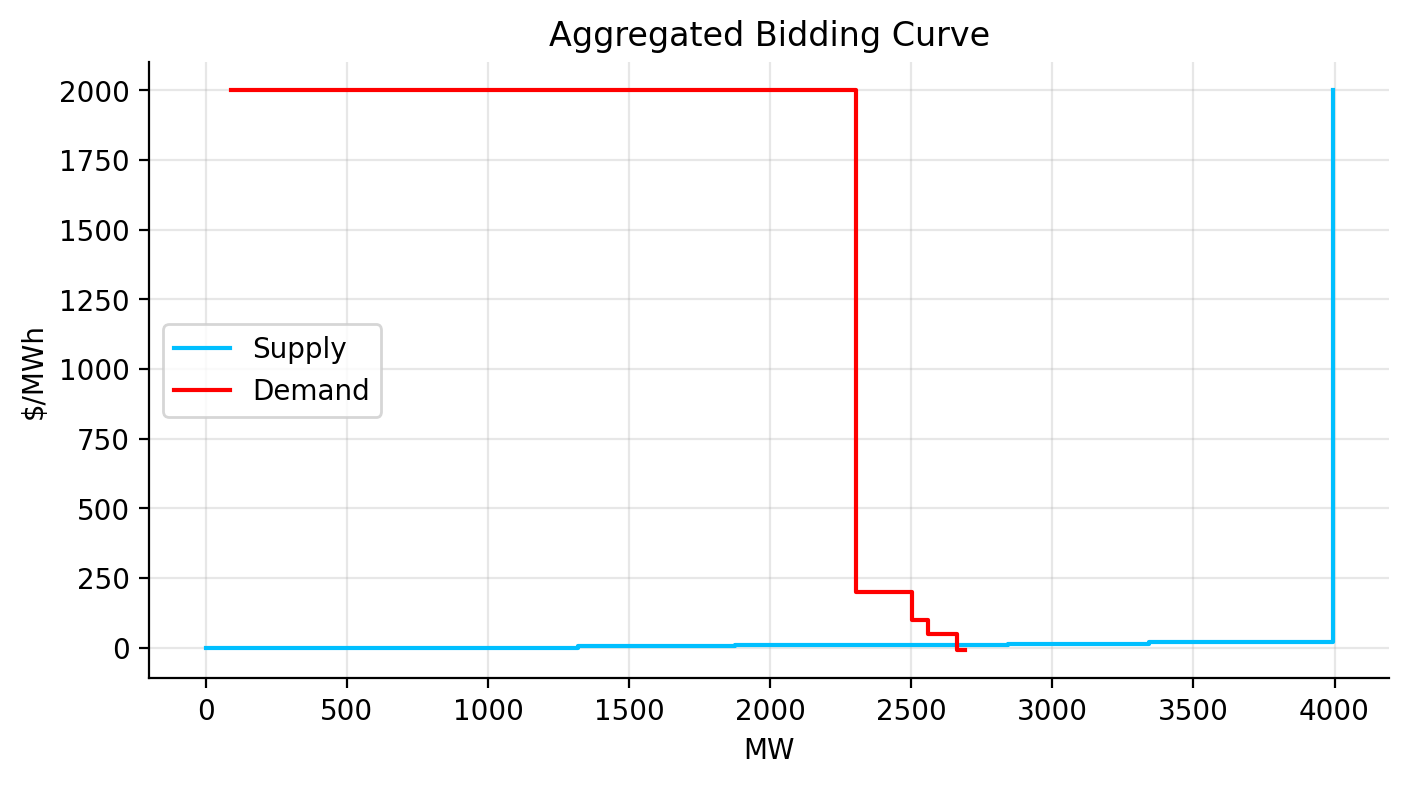

In [16]:
# figure
plt.figure(figsize=(8, 4), dpi=200)

# Plot merit order 
plt.step([0] + merit_order['Cumulative_Pmax'].tolist() + [merit_order['Cumulative_Pmax'].iloc[-1]], 
         [merit_order['Ci_$/MWh'].iloc[0]] + merit_order['Ci_$/MWh'].tolist() + [demand_bid['Price_$/MWh'].max()], 
         where='post', label='Supply', color='deepskyblue')

# Plot demand curve
plt.step(demand_bid['Cumulative_Demand_MW'],
          demand_bid['Price_$/MWh'], 
          where='post', label='Demand', color='red')

# Add labels
plt.xlabel('MW')
plt.ylabel('$/MWh')
plt.title('Aggregated Bidding Curve')

# Format plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

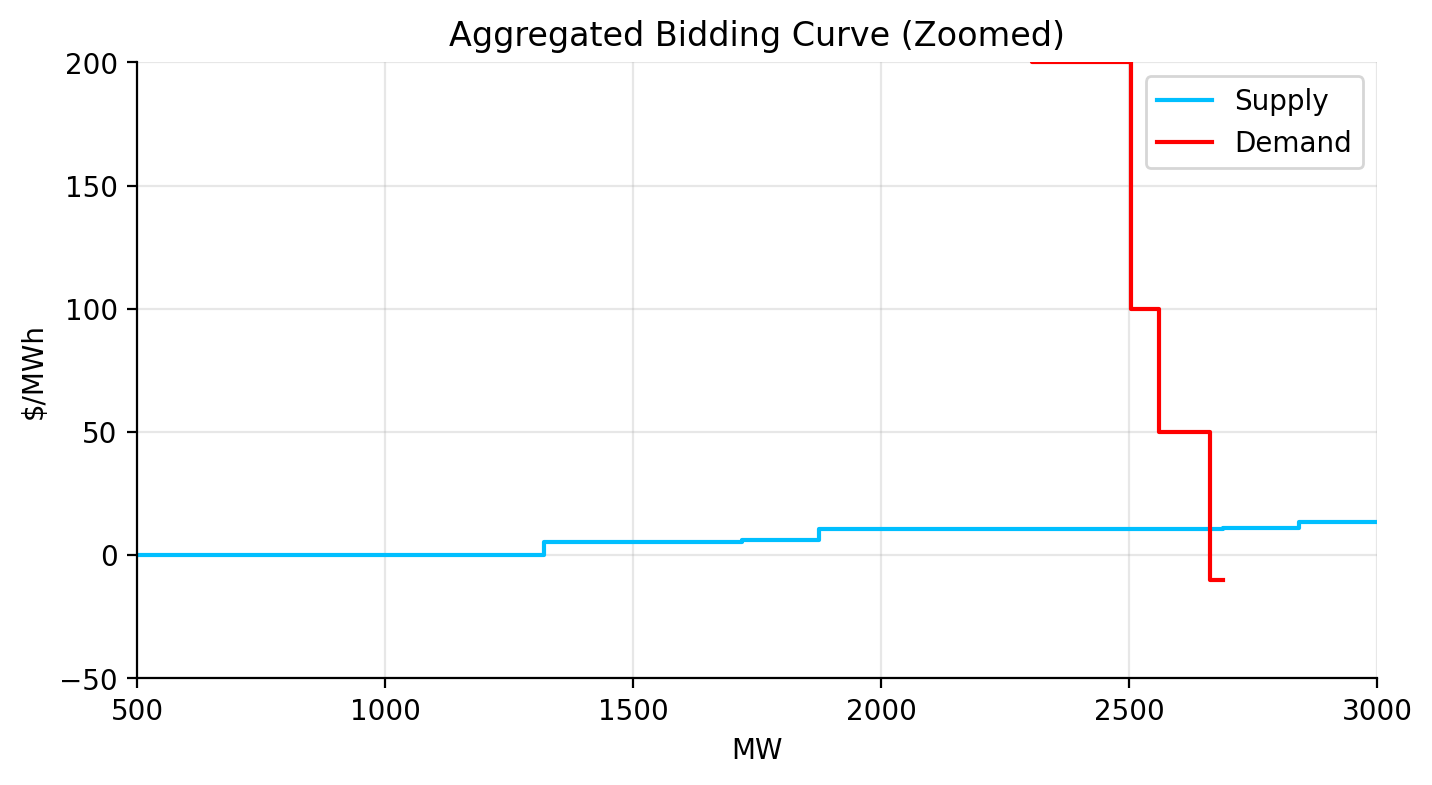

In [17]:
# zoom in to the plot around the intersection point
# figure
plt.figure(figsize=(8, 4), dpi=200)

# Plot merit order 
plt.step([0] + merit_order['Cumulative_Pmax'].tolist() + [merit_order['Cumulative_Pmax'].iloc[-1]], 
         [merit_order['Ci_$/MWh'].iloc[0]] + merit_order['Ci_$/MWh'].tolist() + [demand_bid['Price_$/MWh'].max()], 
         where='post', label='Supply', color='deepskyblue')

# Plot demand curve
plt.step(demand_bid['Cumulative_Demand_MW'],
          demand_bid['Price_$/MWh'], 
          where='post', label='Demand', color='red')

# Add labels
plt.xlabel('MW')
plt.ylabel('$/MWh')
plt.title('Aggregated Bidding Curve (Zoomed)')

# zoom in
plt.xlim(500, 3000)
plt.ylim(-50, 200)

# Format plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Model

In [18]:
model = linopy.Model()

# Decision variables: generation
g = model.add_variables(
    coords=[available_generation['Unit']],
    name="dispatch"
)

# Decision variables: demand
d = model.add_variables(
    lower=0,
    coords=[demand_bid['bid']],
    name="demand"
)

# Capacity constraints
capacity_constraints = model.add_constraints(
    g <= available_generation['Pmax_MW'].values,
    name="capacity_limit"
)

# min_generation_constraint
min_capacity_constraints = model.add_constraints(
    g>=0,
    name="min_generation_constraint"
)


# Demand constraints
demand_constraints = model.add_constraints(
    d <= demand_bid['Quantity_MW'].values,
    name="demand_limit"
)

# Power balance constraint
balance = model.add_constraints(
    g.sum(dim="dim_0") == d.sum(dim="dim_0"),
    name="power_balance"
)

# Objective: minimize negative social welfare
model.add_objective(
    (g * available_generation['Ci_$/MWh'].values).sum() - (d * demand_bid['Price_$/MWh'].values).sum(),
    sense="min"
) 

In [19]:
model.solve(solver_name="highs")

Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-jrebuvoy has 82 rows; 63 cols; 144 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [5e+00, 2e+03]
  Bound   [0e+00, 0e+00]
  RHS     [3e+00, 6e+02]
Presolving model
1 rows, 63 cols, 63 nonzeros  0s
1 rows, 14 cols, 14 nonzeros  0s
Dependent equations search running on 1 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
1 rows, 14 cols, 14 nonzeros  0s
Presolve reductions: rows 1(-81); columns 14(-49); nonzeros 14(-130) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.0s
          1    -4.5691866357e+06 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-jrebuvoy
Model status        : Optimal
Simplex   iterations: 1


('ok', 'optimal')

### Results and Analysis

In [20]:
spot_price = balance.dual.values
print(f"Market clearing price: {spot_price:.2f} $/MWh")

Market clearing price: 10.89 $/MWh


In [21]:
social_welfare = -model.objective.value
print(f"Social welfare: {social_welfare:,.2f} $")

Social welfare: 4,569,186.64 $


In [22]:
# Calculate the profit for each generator
g_solution = g.solution.to_dataframe().reset_index()
g_solution.columns = ['Unit', 'Generation_MW']
g_solution = g_solution.merge(available_generation, on='Unit', how='left')

g_solution['Revenue_$'] = g_solution['Generation_MW'] * spot_price
g_solution['Profit_$'] = g_solution['Generation_MW'] * (spot_price - g_solution['Ci_$/MWh'])

print("The profit for each generator is:")
print(g_solution[['Unit', 'Profit_$']].sort_values('Profit_$', ascending=False))

The profit for each generator is:
   Unit  Profit_$
9   G10  3267.000
8    G9  2168.000
7    G8  1948.000
14   W3  1931.886
17   W6  1611.720
16   W5  1470.150
13   W2   810.216
12   W1   509.652
15   W4   415.998
10  G11   114.700
5    G6    57.350
6    G7    57.350
4    G5     0.000
3    G4     0.000
1    G2     0.000
11  G12     0.000
2    G3     0.000
0    G1     0.000


In [23]:
# Marginating units
g_solution[g_solution['Ci_$/MWh']==spot_price]

,Unit,Generation_MW,Pmax_MW,Ci_$/MWh,Revenue_$,Profit_$
11,G12,310.7,350.0,10.89,3383.523,0.0


In [24]:
# Calculate the utility for each load
d_solution = d.solution.to_dataframe().reset_index()
d_solution.columns = ['bid', 'Demand_MW']
d_solution = d_solution.merge(demand_bid, on='bid', how='left')
d_solution['Utility_$'] = d_solution['Demand_MW'] * (d_solution['Price_$/MWh'] - spot_price)

utility_per_load = d_solution.groupby('Load')['Utility_$'].sum().sort_values(ascending=False).reset_index()
print("The utility for each load is:")
print(utility_per_load)

The utility for each load is:
    Load      Utility_$
0     15  616839.918435
1     13  585207.102105
2     11  490308.653115
3      3  332144.571465
4     12  323810.206740
5     10  323810.206740
6     16  304762.547520
7      9  290476.803105
8      8  285714.888300
9      6  253062.530640
10     1  180952.762590
11    14  166667.018175
12     5  119047.870125
13    17   85173.684975
14     7   83280.936420
15     2   64353.450870
16     4   49211.462430


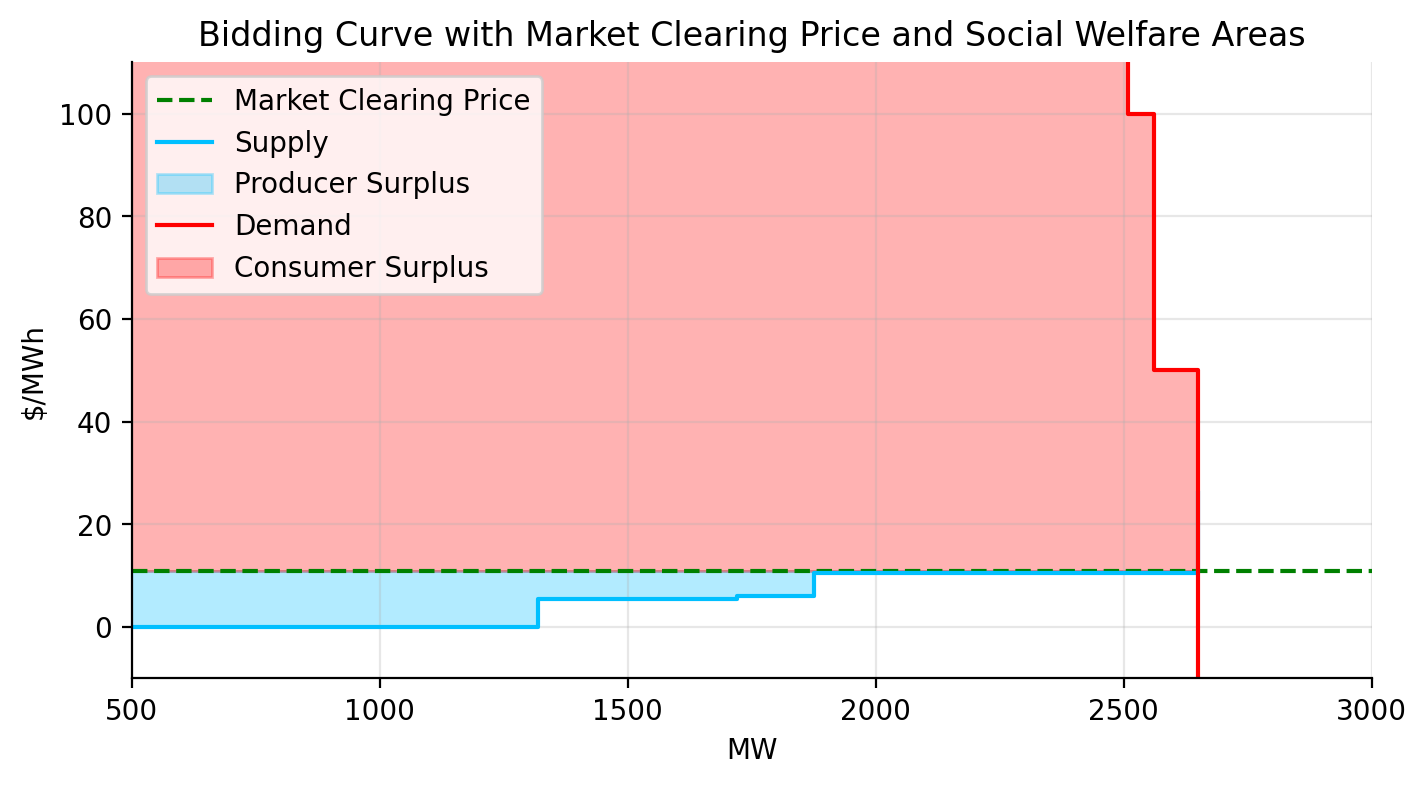

In [25]:
### plot bidding curve with the solution and the area of the social welfare
plt.figure(figsize=(8, 4), dpi=200)

# Plot solution point as a dashed horizontal line
plt.axhline(spot_price, color='green', linestyle='--', label='Market Clearing Price')


# Shade the area of social welfare for the generators
g_ordered = g_solution.sort_values(by='Ci_$/MWh')
g_ordered['Cumulative_Generation'] = g_ordered['Generation_MW'].cumsum()

# Build step-wise x and y
x = np.insert(g_ordered['Cumulative_Generation'].values, 0, 0)
y = np.insert(g_ordered['Ci_$/MWh'].values, 0, g_ordered['Ci_$/MWh'].iloc[0])

# plot the merit order curve
plt.step(x, y, where='post', label='Supply', color='deepskyblue')

# Shade producer surplus
plt.fill_between(
    x,
    y,
    spot_price,
    where=(spot_price >= y),
    step='post',
    alpha=0.3,
    color='deepskyblue',
    label='Producer Surplus'
)
    
# Shade the area of social welfare for the consumers
d_ordered = d_solution.sort_values(by='Price_$/MWh', ascending=False)
d_ordered['Cumulative_Demand'] = d_ordered['Demand_MW'].cumsum()
# Build step-wise x and y
x_d = np.insert(d_ordered['Cumulative_Demand'].values, 0, 0)
y_d = np.insert(d_ordered['Price_$/MWh'].values, 0, d_ordered['Price_$/MWh'].iloc[0])

# plot the demand curve
plt.step(x_d, y_d, where='post', label='Demand', color='red')

# Shade consumer surplus
plt.fill_between(
    x_d,
    y_d,
    spot_price,
    where=(spot_price <= y_d),
    step='post',
    alpha=0.3,
    color='red',
    label='Consumer Surplus'
)

    

# Add labels
plt.xlabel('MW')
plt.ylabel('$/MWh')
plt.title('Bidding Curve with Market Clearing Price and Social Welfare Areas')

# zoom in
plt.xlim(500, 3000)
plt.ylim(-10, 110)

# Format plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [26]:
# Check KKT condition for G12
print("KKT condition for G12 (derivative of Lagrangian w.r.t. dispatch[G12])\n")
print("Ci_$/MWh (G12) + μ_max[G12] - μ_min[G12] - λ = 0\n")
print("μ_max[G12]*g12=0 ^ μ_min[G12]*g12=0\n")
print("Where:")
print(" - μ_max[G12] is the dual variable for the upper bound (capacity constraint) of G12")
print(" - μ_min[G12] is the dual variable for the lower bound (min generation constraint) of G12")
print(" - λ_balance is the dual variable for the power balance constraint (market clearing price)\n")
print("Given that g12>0, then μ_max[G12]=0 and μ_min[G12]=0, and we get:\n")
print(f"{available_generation.loc[available_generation['Unit']=='G12', 'Ci_$/MWh'].values[0]} - λ = 0")

KKT condition for G12 (derivative of Lagrangian w.r.t. dispatch[G12])

Ci_$/MWh (G12) + μ_max[G12] - μ_min[G12] - λ = 0

μ_max[G12]*g12=0 ^ μ_min[G12]*g12=0

Where:
 - μ_max[G12] is the dual variable for the upper bound (capacity constraint) of G12
 - μ_min[G12] is the dual variable for the lower bound (min generation constraint) of G12
 - λ_balance is the dual variable for the power balance constraint (market clearing price)

Given that g12>0, then μ_max[G12]=0 and μ_min[G12]=0, and we get:

10.89 - λ = 0
